# 🤖 XGBoost Machine Learning Report: Dự Đoán `long_mfe` / `short_mae`

## 📌 Mục Tiêu Phân Tích & Bối Cảnh
Notebook này thực hiện huấn luyện, phân tích hiệu năng và dự đoán mục tiêu **`long_mfe`** (Maximum Favorable Excursion của lệnh Long) và **`short_mae`** (Maximum Adverse Excursion của lệnh Short).

### 🎯 So sánh kịch bản:
1. **Random Shuffle Split (80/20)**: Tái lập báo cáo `report.md` ($R^2 \approx 0.5056$, MAE $\approx 0.317$).
2. **Time-Series Split (All Features ~658)**: Đánh giá thực tế không rò rỉ dữ liệu.
3. **Time-Series Split (Top 20 Features)**: Tối ưu hóa độ phức tạp mô hình.


In [1]:
# 1. Imports & Setup
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
print('✔ Thư viện sẵn sàng!')

✔ Thư viện sẵn sàng!


In [2]:
# 2. Load Dataset
feature_path = '/home/v002353/Desktop/SN/04. TPO/fl-data-profiler/datasets/feature.parquet'
label_path = '/home/v002353/Desktop/SN/04. TPO/fl-data-profiler/datasets/label.csv'

features = pd.read_parquet(feature_path)
labels = pd.read_csv(label_path)

if 'Date' in features.columns:
    features['Date'] = pd.to_datetime(features['Date'])
    labels['Date'] = pd.to_datetime(labels['Date'])
    df = pd.merge(features, labels, on='Date', how='inner')
else:
    features.index = pd.to_datetime(features.index)
    labels['Date'] = pd.to_datetime(labels['Date'])
    df = features.merge(labels, left_index=True, right_on='Date', how='inner')

target_col = 'long_mfe'
df_clean = df.dropna(subset=[target_col]).copy()

all_label_cols = ['allow_entry', 'remain_session_volatility', 'remain_session_net_move', 
                  'long_mae', 'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short', 
                  'eod_return_long', 'eod_return_short', 'price_range', 'intraday_position', 'price_shape']
drop_metadata = ['Date', 'trade_date', 'session_start_time', 'session_end_time']
drop_cols = [c for c in all_label_cols if c in df_clean.columns] + [c for c in drop_metadata if c in df_clean.columns]

y = df_clean[target_col]
X_raw = df_clean.drop(columns=drop_cols, errors='ignore')
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
X = X_raw[numeric_cols].replace([np.inf, -np.inf], np.nan)
nan_ratio = X.isnull().mean()
valid_features = nan_ratio[nan_ratio < 0.5].index.tolist()
X = X[valid_features].fillna(X.median())
print(f'✔ Targets `long_mfe`: {len(X):,} dòng, {X.shape[1]} features.')

✔ Targets `long_mfe`: 91,866 dòng, 658 features.


In [3]:
# 3. Random Shuffle Split vs Time-Series Split
df_20k = df_clean.sample(n=min(20000, len(df_clean)), random_state=42)
y_20k = df_20k[target_col]
X_20k = df_20k[numeric_cols].replace([np.inf, -np.inf], np.nan)[valid_features].fillna(X.median())
x_tr_r, x_te_r, y_tr_r, y_te_r = train_test_split(X_20k, y_20k, test_size=0.2, random_state=42)

model_r = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1)
model_r.fit(x_tr_r, y_tr_r)
p_te_r = model_r.predict(x_te_r)
r2_r = r2_score(y_te_r, p_te_r)
mae_r = mean_absolute_error(y_te_r, p_te_r)
rmse_r = np.sqrt(mean_squared_error(y_te_r, p_te_r))

# Time-Series Split
split_idx = int(len(X) * 0.8)
X_train_ts, X_test_ts = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_ts, y_test_ts = y.iloc[:split_idx], y.iloc[split_idx:]

model_ts_all = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.08, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
model_ts_all.fit(X_train_ts, y_train_ts)
p_te_ts_all = model_ts_all.predict(X_test_ts)
r2_ts_all = r2_score(y_test_ts, p_te_ts_all)
mae_ts_all = mean_absolute_error(y_test_ts, p_te_ts_all)
rmse_ts_all = np.sqrt(mean_squared_error(y_test_ts, p_te_ts_all))

# Top 20
imp = pd.Series(model_ts_all.feature_importances_, index=X.columns).sort_values(ascending=False)
top20_cols = imp.head(20).index.tolist()

model_ts_20 = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.08, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
model_ts_20.fit(X_train_ts[top20_cols], y_train_ts)
p_te_ts_20 = model_ts_20.predict(X_test_ts[top20_cols])
r2_ts_20 = r2_score(y_test_ts, p_te_ts_20)
mae_ts_20 = mean_absolute_error(y_test_ts, p_te_ts_20)
rmse_ts_20 = np.sqrt(mean_squared_error(y_test_ts, p_te_ts_20))

bench_df = pd.DataFrame({
    'Kịch Bản': ['1. Random Shuffle (report.md)', '2. Time-Series (All Feats)', '3. Time-Series (Top 20 Feats)'],
    'Test R²': [round(r2_r, 4), round(r2_ts_all, 4), round(r2_ts_20, 4)],
    'Test MAE': [round(mae_r, 4), round(mae_ts_all, 4), round(mae_ts_20, 4)],
    'Test RMSE': [round(rmse_r, 4), round(rmse_ts_all, 4), round(rmse_ts_20, 4)]
})
display(bench_df)

,Kịch Bản,Test R²,Test MAE,Test RMSE
0,1. Random Shuffle (report.md),0.4958,0.3274,0.4881
1,2. Time-Series (All Feats),0.1166,0.4028,0.6638
2,3. Time-Series (Top 20 Feats),0.0512,0.4121,0.6880


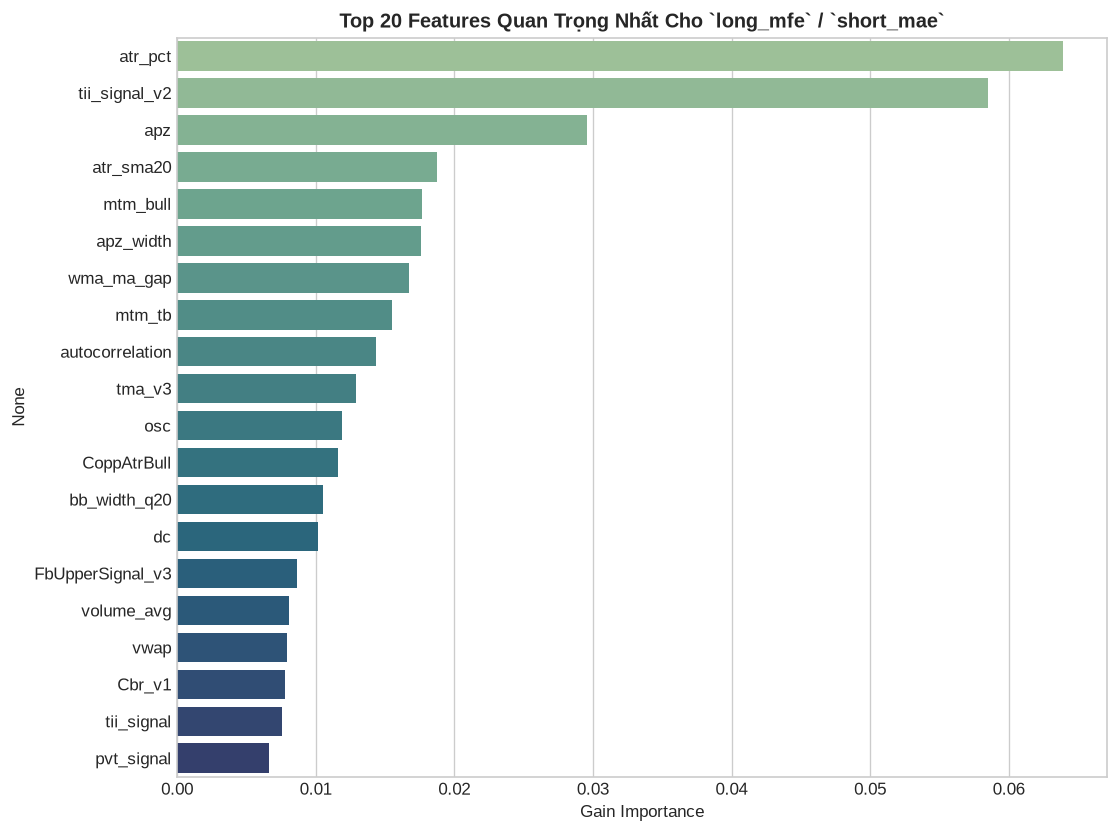

In [4]:
# 4. Feature Importance Top 20
plt.figure(figsize=(10, 8))
sns.barplot(x=imp.head(20).values, y=imp.head(20).index, palette='crest')
plt.title('Top 20 Features Quan Trọng Nhất Cho `long_mfe` / `short_mae`', fontweight='bold')
plt.xlabel('Gain Importance')
plt.show()